In [1]:
%pwd

'/data/lab/jianyu/git/TPCAV/examples'

In [2]:
import torch
from tpcav import run_tpcav, helper

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
#==================== Prepare Model and Data transform function ================================
class DummyModelSeq(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layer_1 = torch.nn.Sequential(
            torch.nn.Conv1d(4, 64, 25, padding=12, bias=True),
            torch.nn.BatchNorm1d(64),
            torch.nn.LeakyReLU()
        )
        self.conv_layer_2 = torch.nn.Sequential(
            torch.nn.Conv1d(64, 128, 3, padding=1, stride=2, bias=True),
            torch.nn.BatchNorm1d(128),
            torch.nn.LeakyReLU(),
        )

        self.linear_layer_1 = torch.nn.Sequential(
            torch.nn.Linear(512, 1),
            torch.nn.LeakyReLU()
        )
        self.linear_layer_2 = torch.nn.Linear(128, 1)

    def forward(self, seq):
        y_hat = self.conv_layer_1(seq)
        y_hat = self.conv_layer_2(y_hat)
        y_hat = self.linear_layer_1(y_hat)
        y_hat = y_hat.squeeze(-1)
        y_hat = self.linear_layer_2(y_hat)
        return y_hat

/home/jmy5455/miniforge3/envs/test/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## model training

In [32]:
ctcf_peaks = helper.load_bed_and_center("data/MCF-7_CTCF_ENCFF942TCG.bed", window=1024)
ctcf_peaks = ctcf_peaks.loc[ctcf_peaks.chrom != 'chrM']
ctcf_peaks

,chrom,start,end
0,chr17,75754688,75755712
1,chr3,127747022,127748046
2,chr22,46130993,46132017
3,chr3,139677291,139678315
4,chr8,123394394,123395418
...,...,...,...
56198,chr20,58209484,58210508
56199,chr17,45134930,45135954
56200,chr9,128117284,128118308
56201,chr1,150979121,150980145


In [33]:
random_regs = helper.random_regions_dataframe("data/hg38.analysisSet.fa.fai", window=1024, n=len(ctcf_peaks))
random_regs = random_regs.loc[random_regs.chrom != 'chrM']
random_regs

,chrom,start,end
0,chr8,39267215,39268239
1,chr17,43229869,43230893
2,chr2,73528924,73529948
3,chr8,86008837,86009861
4,chr10,50239667,50240691
...,...,...,...
56179,chr4,76365762,76366786
56180,chr3,27330197,27331221
56181,chr14,1634799,1635823
56182,chr3,49255000,49256024


In [34]:
from sklearn.model_selection import train_test_split

train_df_pos, test_df_pos = train_test_split(ctcf_peaks, test_size=0.05)
train_df_neg, test_df_neg = train_test_split(random_regs, test_size=0.05)

In [35]:
def df_to_one_hot_iter(df, infinite=False):
    it = iter(helper.dataframe_to_fasta_iter(df, "data/hg38.analysisSet.fa", batch_size=8))
    while True:
        try:
            yield helper.fasta_to_one_hot_sequences(next(it))
        except StopIteration:
            if infinite:
                it = iter(helper.dataframe_to_fasta_iter(df, "data/hg38.analysisSet.fa", batch_size=8))
                yield helper.fasta_to_one_hot_sequences(next(it))
            else:
                return
        

In [36]:
def compute_loss(model, seq_pos, seq_neg):
    label_pos = torch.ones(seq_pos.shape[0])
    label_neg = torch.zeros(seq_neg.shape[0])
    label = torch.cat([label_pos, label_neg]).unsqueeze(-1).to(seq_pos.device)
    
    y_pred = model(torch.cat([seq_pos, seq_neg]))
    loss = torch.nn.functional.binary_cross_entropy_with_logits(y_pred, label)

    return loss

def eval_model(model):
    model.eval()
    losses = []
    for seq_pos, seq_neg in zip(df_to_one_hot_iter(test_df_pos), df_to_one_hot_iter(test_df_neg)):
        loss = compute_loss(model, seq_pos.to(device), seq_neg.to(device))
        losses.append(loss.unsqueeze(-1).detach())
    losses = torch.cat(losses).mean()
    model.train()
    return losses

model = DummyModelSeq()
model.to(device)
model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

training_losses = []
best_eval_loss = 100
early_stop_counter = 0
max_epochs = 100000
patience = 100
for i, (seq_pos, seq_neg) in enumerate(zip(df_to_one_hot_iter(train_df_pos, infinite=True), df_to_one_hot_iter(train_df_neg, infinite=True))):

    loss = compute_loss(model, seq_pos.to(device), seq_neg.to(device))
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

    if i % 100 == 0:
        eval_loss = eval_model(model)
        if eval_loss < best_eval_loss:
            best_eval_loss = eval_loss.item()
            torch.save(model, 'data/mcf7_ctcf_best.pt')
        else:
            early_stop_counter += 1
            if early_stop_counter > patience:
                break

        if i > max_epochs: break
        #print(f"Training loss after batch {i}: {loss}")
        print(f"Evaluation loss after batch {i}: {eval_loss}")


Evaluation loss after batch 0: 0.6937556266784668
Evaluation loss after batch 100: 0.6942372918128967
Evaluation loss after batch 200: 0.6925637722015381
Evaluation loss after batch 300: 0.6919495463371277
Evaluation loss after batch 400: 0.6913040280342102
Evaluation loss after batch 500: 0.6903418898582458
Evaluation loss after batch 600: 0.6883369088172913
Evaluation loss after batch 700: 0.6819443702697754
Evaluation loss after batch 800: 0.6625214219093323
Evaluation loss after batch 900: 0.6370221376419067
Evaluation loss after batch 1000: 0.6176310777664185
Evaluation loss after batch 1100: 0.6073943376541138
Evaluation loss after batch 1200: 0.5926850438117981
Evaluation loss after batch 1300: 0.5794664621353149
Evaluation loss after batch 1400: 0.5670604705810547
Evaluation loss after batch 1500: 0.5582072138786316
Evaluation loss after batch 1600: 0.5516800880432129
Evaluation loss after batch 1700: 0.5421598553657532
Evaluation loss after batch 1800: 0.5393367409706116
Evalu

## test TPCAV

In [3]:
%cd ..

/data/lab/jianyu/git/TPCAV


In [4]:
# By default, every concept extracts fasta sequences and bigwig signals from the given region
# Use your own custom transformation function to get your desired inputs
# Here we transform them into one-hot coded DNA sequences
def transform_fasta_to_one_hot_seq(seq, chrom):
    # `seq` is a list of fasta sequences
    # `chrom` is a numpy array of bigwig signals of shape [-1, # bigwigs, len]
    return (helper.fasta_to_one_hot_sequences(seq),) # it has to return a tuple of inputs, even if there is only one input

INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0001:GATA-PROP:GATA
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0002:PROP-ALX:Homeodomain
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0003:HNF1A-HNF1B:Homeodomain
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0004:ZSCAN:C2H2_ZF
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0005:POU3F-POU1F:Homeodomain,POU
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0078:CTCF-CTCFL:C2H2_ZF
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0111:CTCF-KLF:C2H2_ZF
INFO:tpcav.tpcav_model:Sampled 10 activations from concept random_regions
INFO:tpcav.tpcav_model:Sampled 10 activations from concept SINE/MIR_MIR3
INFO:tpcav.tpcav_model:Sampled 10 activations from concept LINE/L2_L2a
INFO:tpcav.tpcav_model:Sampled 10 activations from concept SINE/MIR_MIR
INFO:tpcav.tpcav_model:Sampled 10 activations from concept LINE/L2_L2b
INFO:tpcav.tpcav_model:Sampled 10 activ

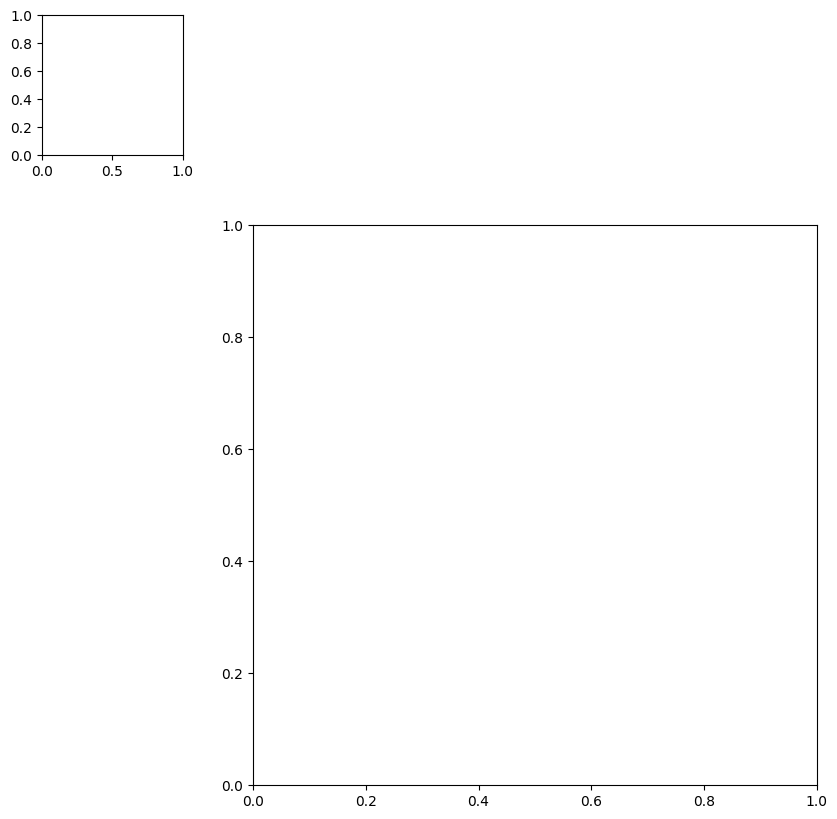

In [5]:
motif_path = "data/motif-clustering-v2.1beta_consensus_pwms.test.meme" # motif file in meme format for constructing motif concepts
bed_seq_concept = "data/hg38_rmsk.sample.bed" # a bed file to supply concepts described by a set of regions, format [chrom, start, end, label, concept_name]
genome_fasta = "data/hg38.analysisSet.fa"
model = torch.load("data/mcf7_ctcf_best.pt", map_location=device, weights_only=False) # load the model
layer_name = "linear_layer_1"   # name of the layer to be interpreted, you should be able to retrieve the layer object by getattr(model, layer_name)

# concept_fscores_dataframe: fscores of each concept
# motif_cav_trainers: each trainer contains the cav weights of motifs inserted different number of times
# bed_cav_trainer: trainer contains the cav weights of the sequence concepts provided in bed file
concept_fscores_dataframe, motif_cav_trainers, bed_cav_trainer = run_tpcav(
    model=model,
    layer_name=layer_name,
    motif_file=motif_path,
    motif_file_fmt='meme',  # specify your motif file format, either meme or consensus (tab delimited file in form [motif_name, consensus_sequence])
    genome_fasta=genome_fasta,
    num_motif_insertions=[12, 24, 36],
    bed_seq_file=bed_seq_concept,
    num_samples_for_cav=500,
    output_dir="test_run_tpcav_output/",
    input_transform_func=transform_fasta_to_one_hot_seq,
    p=4) # number of concurrent SGDClassifier can be run at the same time, increase it if you have available CPU power, it speeds up training significantly

/home/jmy5455/miniforge3/envs/test/lib/python3.14/site-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 1 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/jmy5455/miniforge3/envs/test/lib/python3.14/site-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)
INFO:tpcav.cavs:Skipping CAV AC0001:GATA-PROP:GATA with F-score 0.763 below threshold 0.800
INFO:tpcav.cavs:Skipping CAV AC0003:HNF1A-HNF1B:Homeodomain with F-score 0.747 below threshold 0.800
INFO:tpcav.cavs:Skipping CAV AC0002:PROP-ALX:Homeodomain with F-score 0.617 below threshold 0.800
INFO:tpcav.cavs:Skipping CAV AC0005:POU3F-POU1F:Homeodomain,POU with F-score 0.680 below threshold 0.800
INFO:tpcav.cavs:Skipping C

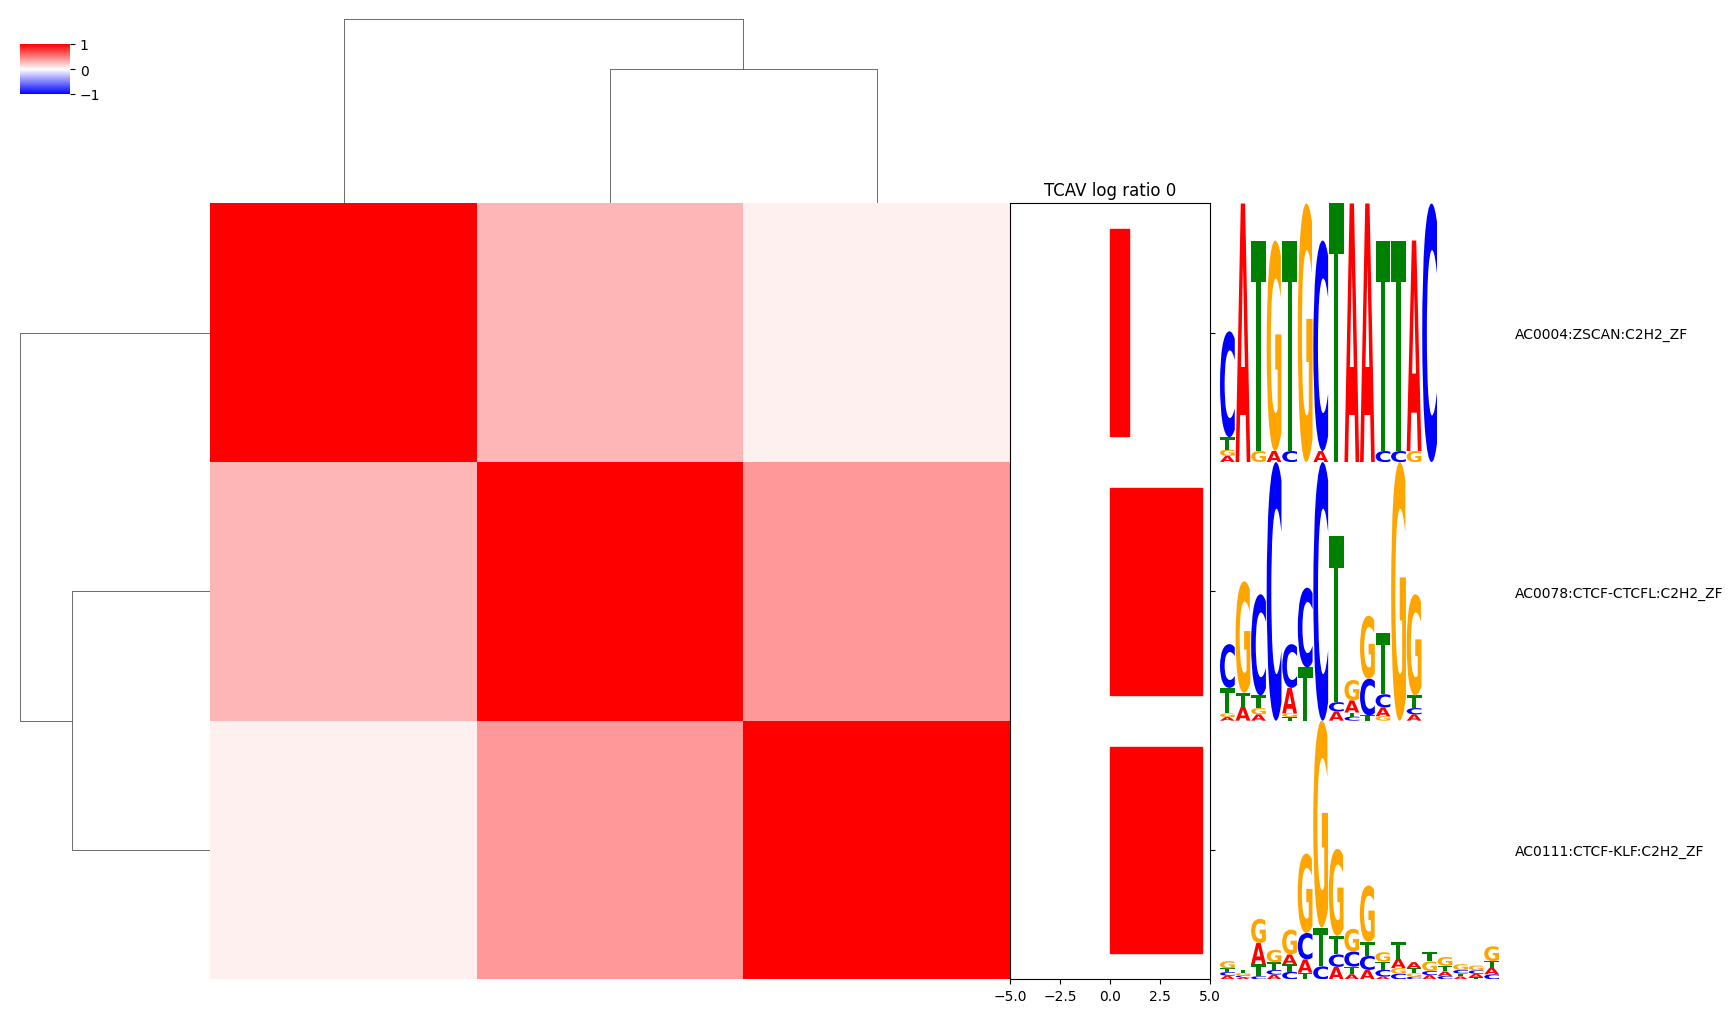

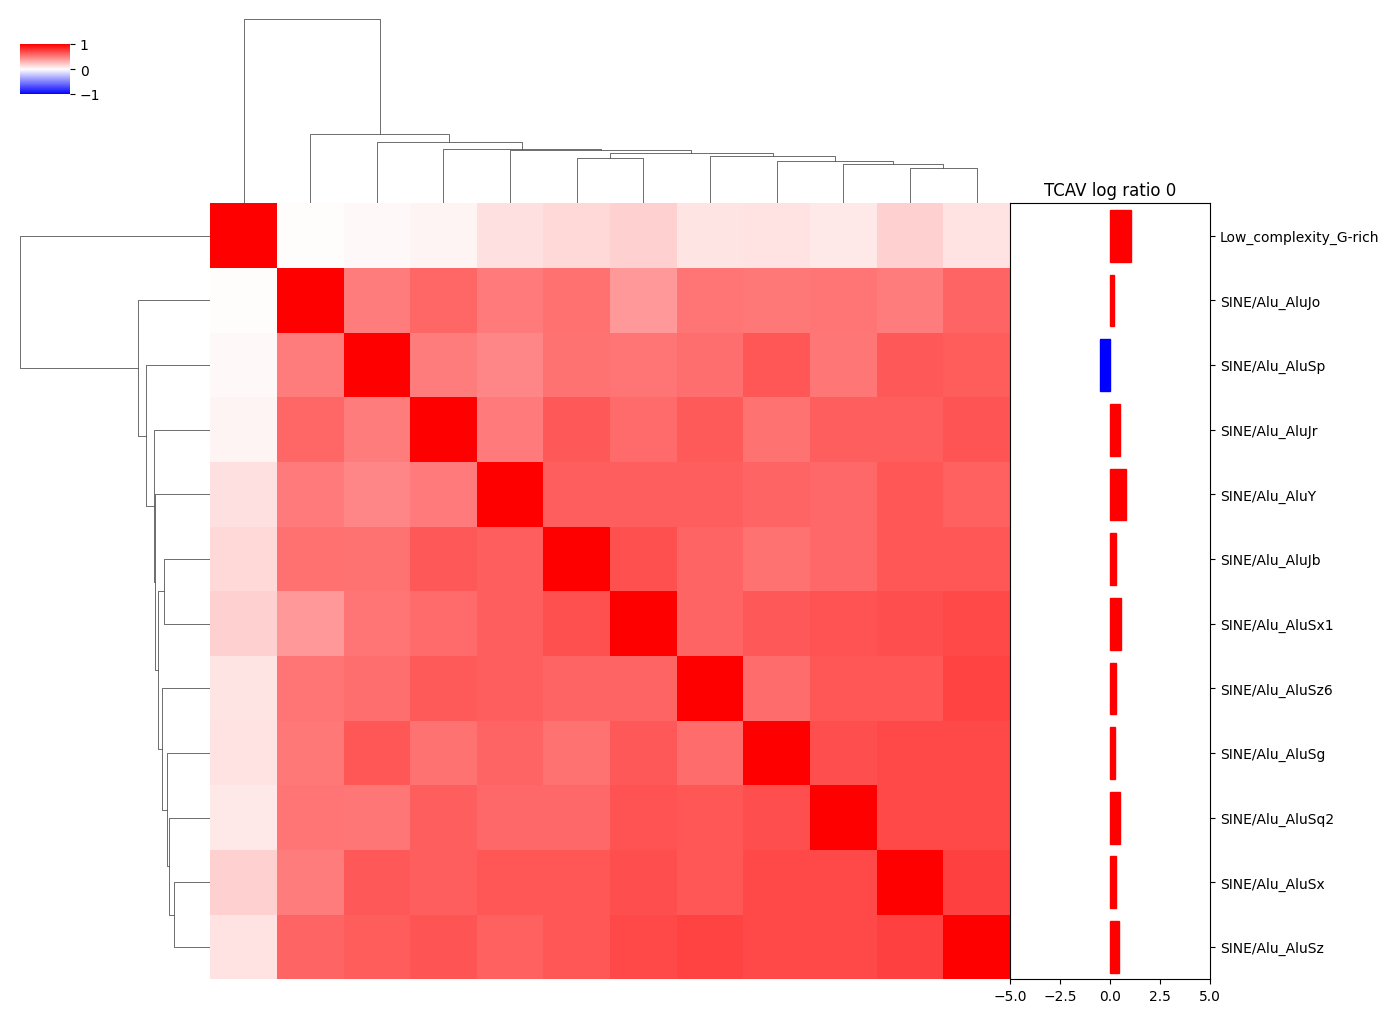

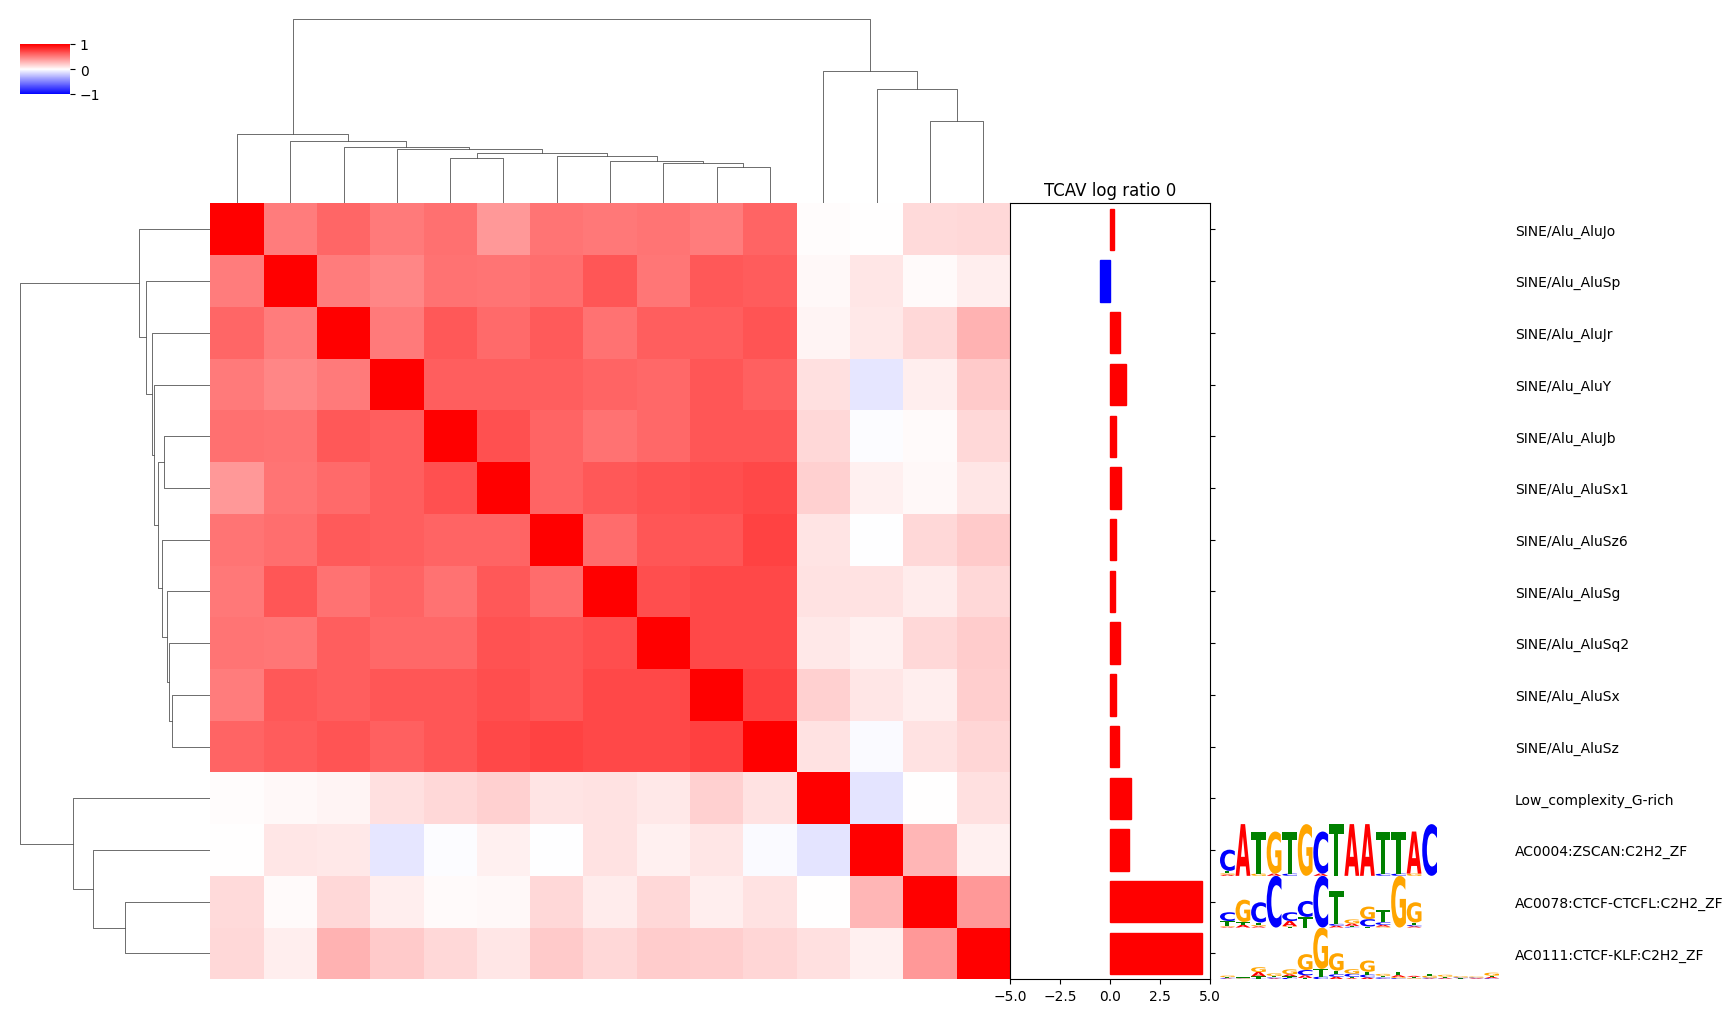

In [6]:
from tpcav import report

#==================== Compuate layer attributions of target testing regions ================================
# retrieve the tpcav model
tpcav_model = bed_cav_trainer.tpcav

# create input regions and baseline regions for attribution
ctcf_peaks = helper.load_bed_and_center("data/MCF-7_CTCF_ENCFF942TCG.bed", window=1024).sample(n=100)
random_regions = helper.random_regions_dataframe(genome_fasta + ".fai", 1024, 100, seed=2)
# create iterators to yield one-hot encoded sequences from the region dataframes
def pack_data_iters(df):
    seq_fasta_iter = helper.dataframe_to_fasta_iter(df, genome_fasta, batch_size=8)
    seq_one_hot_iter = (helper.fasta_to_one_hot_sequences(seq_fasta) for seq_fasta in seq_fasta_iter)
    return zip(seq_one_hot_iter, )
# compute layer attributions given the iterators of testing regions and control regions
attributions = tpcav_model.layer_attributions(pack_data_iters(ctcf_peaks), pack_data_iters(random_regions))
# generate a new html report with TPCAV score computed
report.generate_tpcav_html_report("report_tpcav_score.html", motif_cav_trainers,
                               non_motif_cav_trainers = {'repeats': bed_cav_trainer},
                               attributions = [attributions, ],  # if you have multiple sets of attributions you can provide a list
                               motif_file=motif_path, motif_file_fmt='meme', fscore_thresh=0.8)

# save the trainers for future use
torch.save(motif_cav_trainers, "motif_cav_trainers.pt")
torch.save(bed_cav_trainer, "bed_cav_trainer.pt")

## test

INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0001:GATA-PROP:GATA
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0002:PROP-ALX:Homeodomain
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0003:HNF1A-HNF1B:Homeodomain
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0004:ZSCAN:C2H2_ZF
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0005:POU3F-POU1F:Homeodomain,POU
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0078:CTCF-CTCFL:C2H2_ZF
INFO:tpcav.tpcav_model:Sampled 10 activations from concept AC0111:CTCF-KLF:C2H2_ZF
INFO:tpcav.tpcav_model:Sampled 10 activations from concept random_regions
INFO:tpcav.tpcav_model:Sampled 10 activations from concept SINE/MIR_MIR3
INFO:tpcav.tpcav_model:Sampled 10 activations from concept LINE/L2_L2a
INFO:tpcav.tpcav_model:Sampled 10 activations from concept SINE/MIR_MIR
INFO:tpcav.tpcav_model:Sampled 10 activations from concept LINE/L2_L2b
INFO:tpcav.tpcav_model:Sampled 10 activ

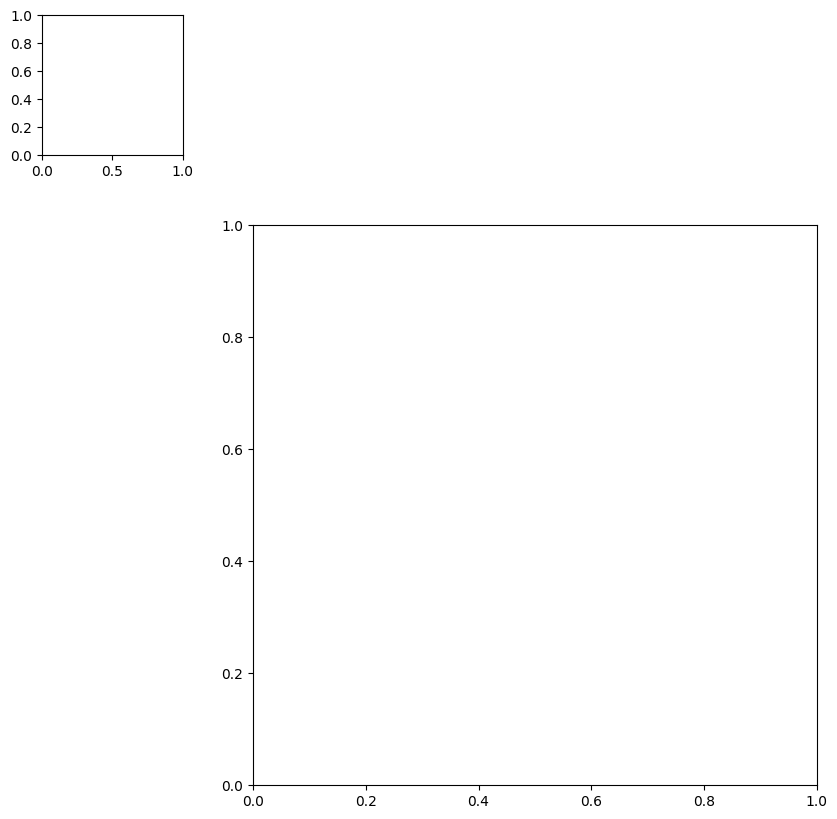

In [3]:
import torch
from tpcav import run_tpcav, helper
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

#==================== Prepare Model and Data transform function ================================
class DummyModelSeq(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layer_1 = torch.nn.Sequential(
            torch.nn.Conv1d(4, 64, 25, padding=12, bias=True),
            torch.nn.BatchNorm1d(64),
            torch.nn.LeakyReLU()
        )
        self.conv_layer_2 = torch.nn.Sequential(
            torch.nn.Conv1d(64, 128, 3, padding=1, stride=2, bias=True),
            torch.nn.BatchNorm1d(128),
            torch.nn.LeakyReLU(),
        )

        self.linear_layer_1 = torch.nn.Sequential(
            torch.nn.Linear(512, 1),
            torch.nn.LeakyReLU()
        )
        self.linear_layer_2 = torch.nn.Linear(128, 1)

    def forward(self, seq):
        y_hat = self.conv_layer_1(seq)
        y_hat = self.conv_layer_2(y_hat)
        y_hat = self.linear_layer_1(y_hat)
        y_hat = y_hat.squeeze(-1)
        y_hat = self.linear_layer_2(y_hat)
        return y_hat

# By default, every concept extracts fasta sequences and bigwig signals from the given region
# Use your own custom transformation function to get your desired inputs
# Here we transform them into one-hot coded DNA sequences
def transform_fasta_to_one_hot_seq(seq, chrom):
    # `seq` is a list of fasta sequences
    # `chrom` is a numpy array of bigwig signals of shape [-1, # bigwigs, len]
    return (helper.fasta_to_one_hot_sequences(seq),) # it has to return a tuple of inputs, even if there is only one input

#==================== Construct concepts ================================
motif_path = "data/motif-clustering-v2.1beta_consensus_pwms.test.meme" # motif file in meme format for constructing motif concepts
bed_seq_concept = "data/hg38_rmsk.sample.bed" # a bed file to supply concepts described by a set of regions, format [chrom, start, end, label, concept_name]
genome_fasta = "data/hg38.analysisSet.fa"
model = torch.load("data/mcf7_ctcf_best.pt", map_location=device, weights_only=False) # load the model
layer_name = "linear_layer_1"   # name of the layer to be interpreted, you should be able to retrieve the layer object by getattr(model, layer_name)

# concept_fscores_dataframe: fscores of each concept
# motif_cav_trainers: each trainer contains the cav weights of motifs inserted different number of times
# bed_cav_trainer: trainer contains the cav weights of the sequence concepts provided in bed file
concept_fscores_dataframe, motif_cav_trainers, bed_cav_trainer = run_tpcav(
    model=model,
    layer_name=layer_name,
    motif_file=motif_path,
    motif_file_fmt='meme',  # specify your motif file format, either meme or consensus (tab delimited file in form [motif_name, consensus_sequence])
    genome_fasta=genome_fasta,
    num_motif_insertions=[12, 24, 36],
    bed_seq_file=bed_seq_concept, 
    output_dir="test_run_tpcav_output/",
    input_transform_func=transform_fasta_to_one_hot_seq,
    p=4) # number of concurrent SGDClassifier can be run at the same time, increase it if you have available CPU power, it speeds up training significantly

/home/jmy5455/miniforge3/envs/test/lib/python3.14/site-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 1 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/jmy5455/miniforge3/envs/test/lib/python3.14/site-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)
INFO:tpcav.cavs:Skipping CAV AC0003:HNF1A-HNF1B:Homeodomain with F-score 0.782 below threshold 0.800
INFO:tpcav.cavs:Skipping CAV AC0002:PROP-ALX:Homeodomain with F-score 0.753 below threshold 0.800
INFO:tpcav.cavs:Skipping CAV AC0001:GATA-PROP:GATA with F-score 0.696 below threshold 0.800
INFO:tpcav.cavs:Skipping CAV AC0111:CTCF-KLF:C2H2_ZF with F-score 0.764 below threshold 0.800
INFO:tpcav.cavs:Skipping CAV AC0005:P

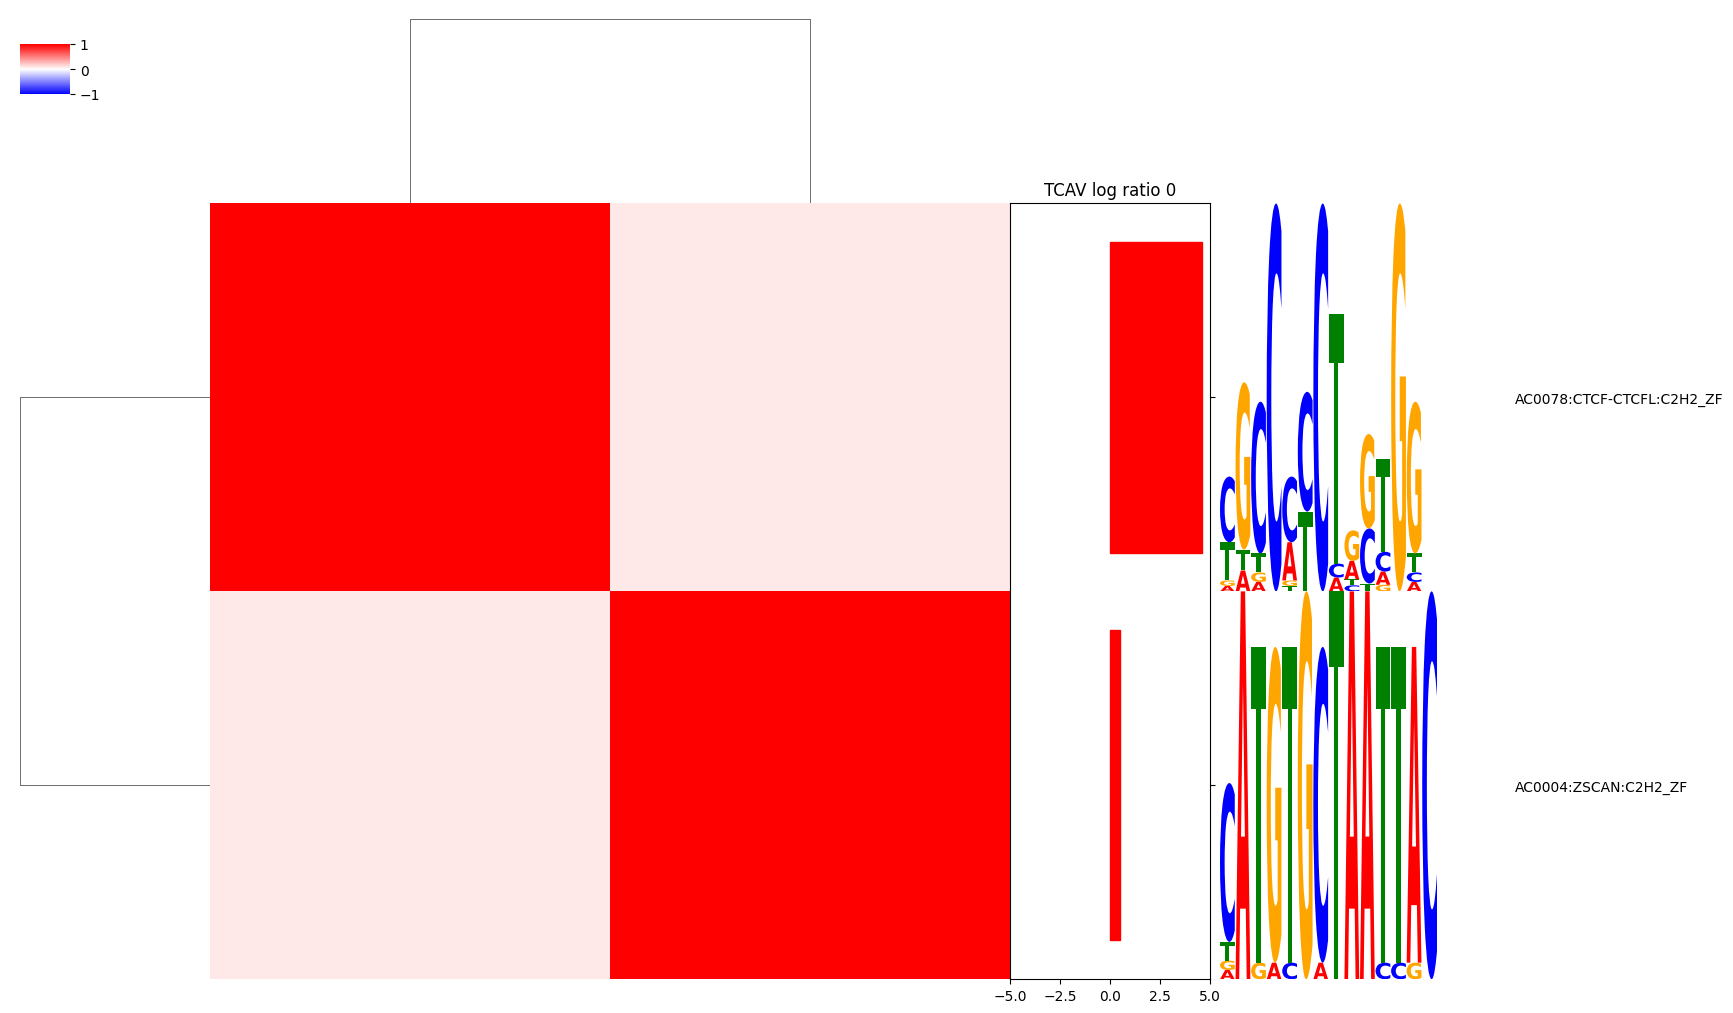

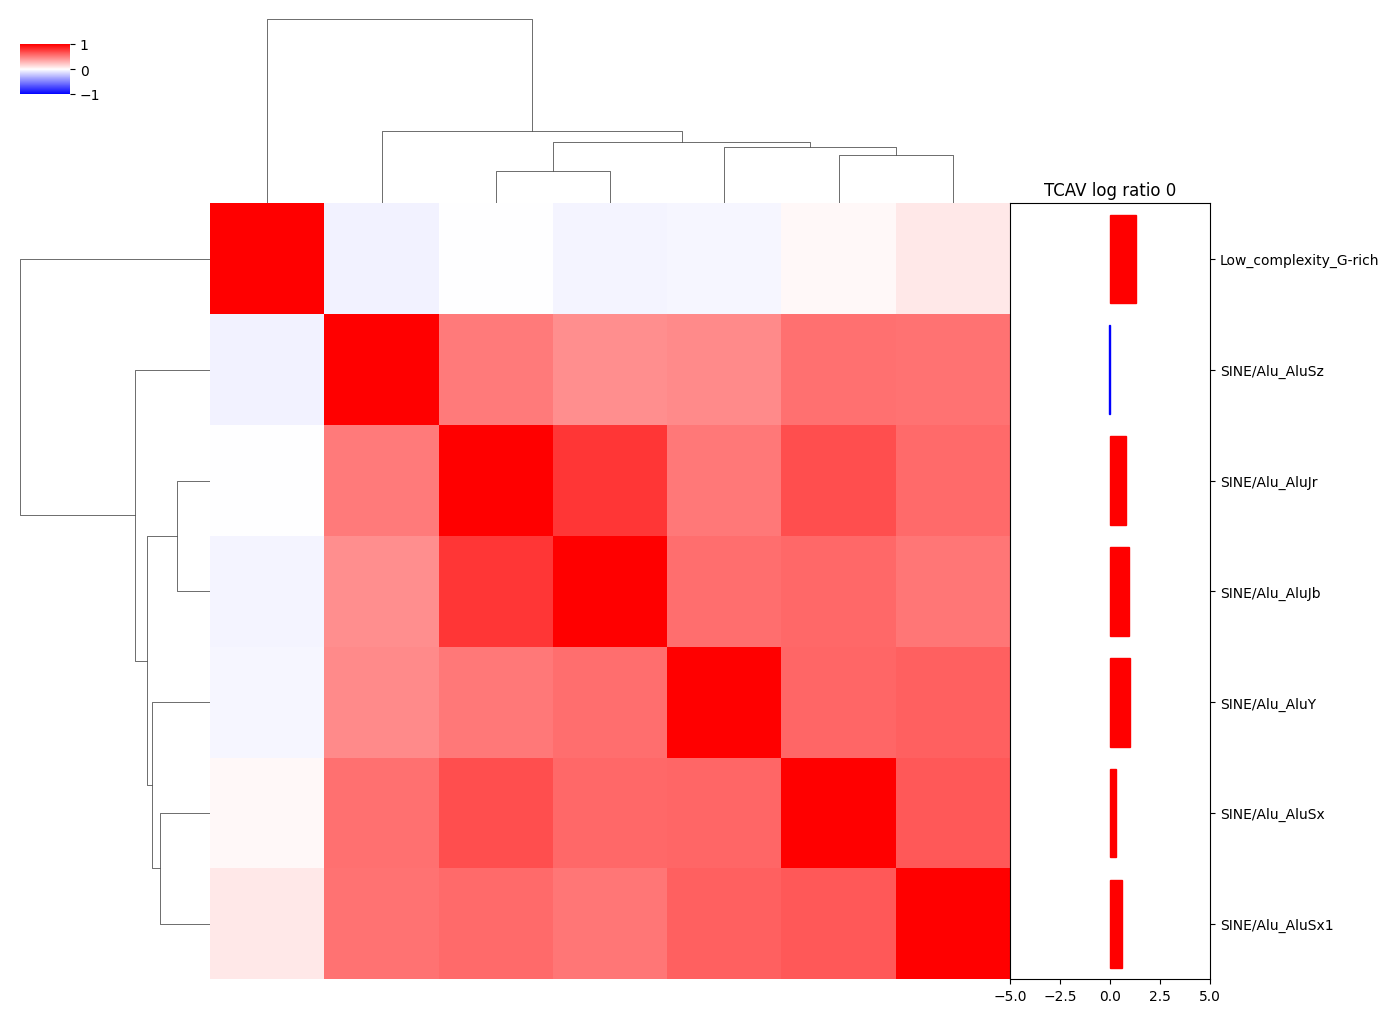

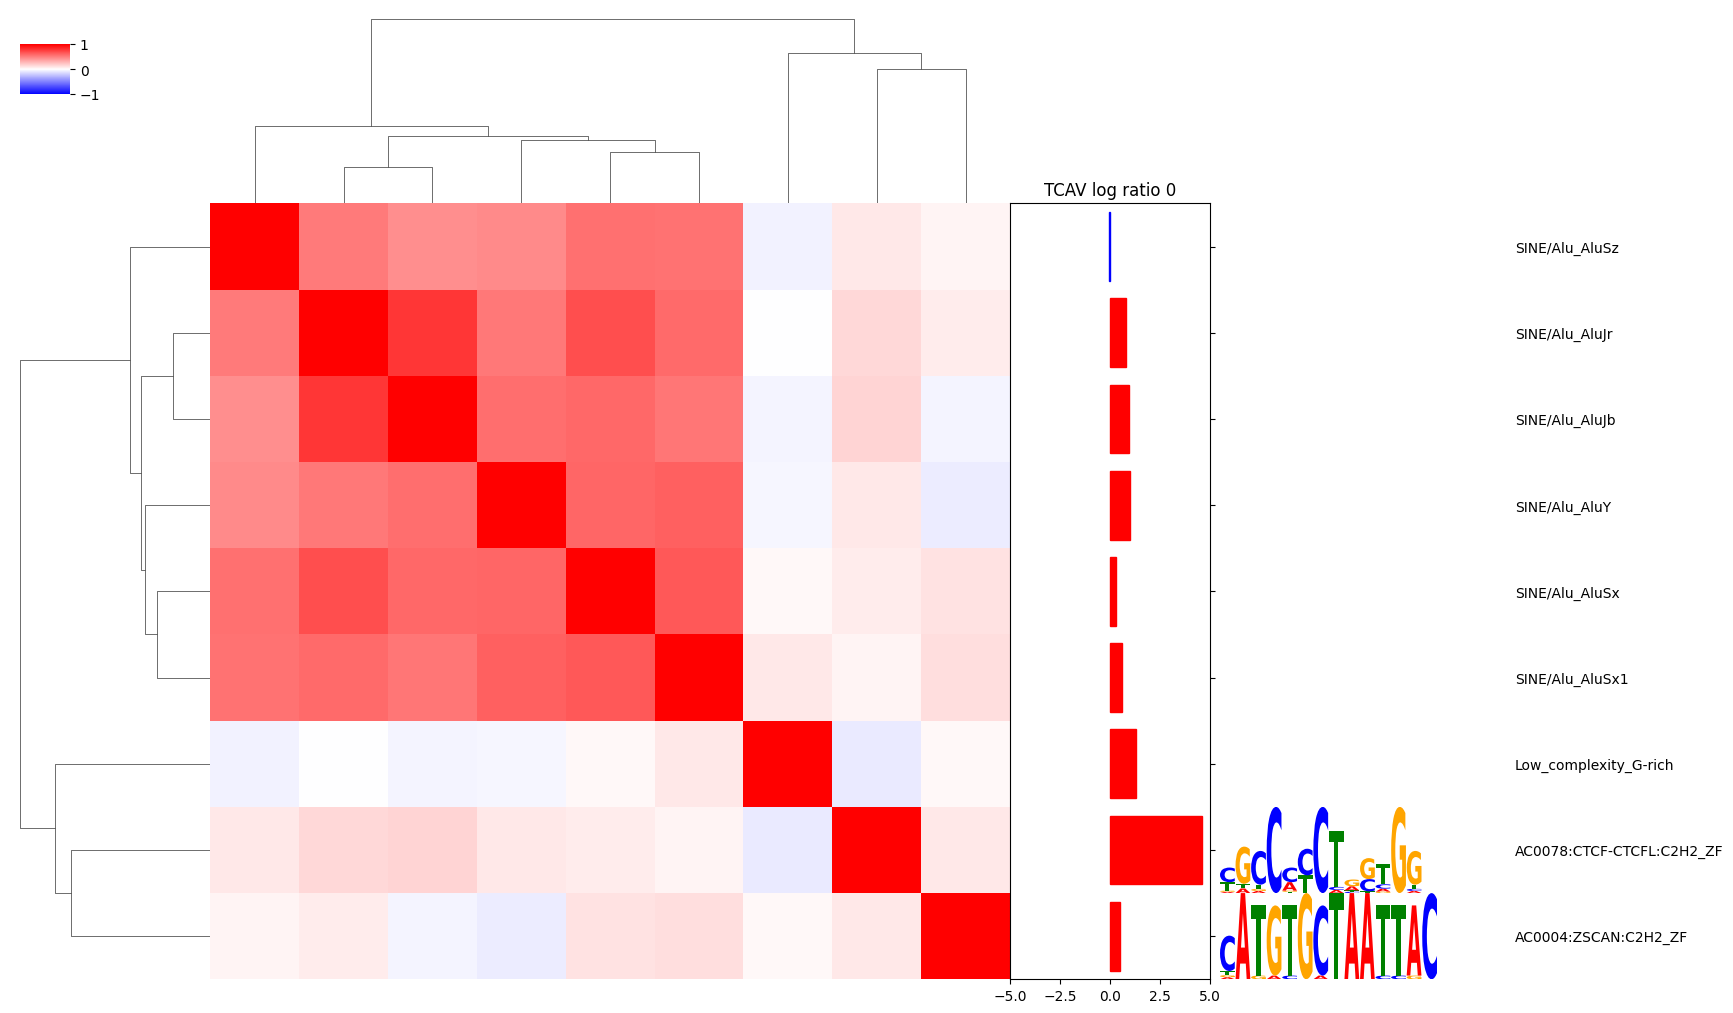

In [4]:
from tpcav import report

#==================== Compuate layer attributions of target testing regions ================================
# retrieve the tpcav model
tpcav_model = bed_cav_trainer.tpcav

# create input regions and baseline regions for attribution
ctcf_peaks = helper.load_bed_and_center("data/MCF-7_CTCF_ENCFF942TCG.bed", window=1024).sample(n=100)
random_regions = helper.random_regions_dataframe(genome_fasta + ".fai", 1024, 100, seed=2)

# create iterators to yield one-hot encoded sequences from the region dataframes
# adjust this funtion to fit your model input format requirements
def pack_data_iters(df):
    seq_fasta_iter = helper.dataframe_to_fasta_iter(df, genome_fasta, batch_size=8)
    seq_one_hot_iter = (helper.fasta_to_one_hot_sequences(seq_fasta) for seq_fasta in seq_fasta_iter)
    return zip(seq_one_hot_iter, )

# compute layer attributions given the iterators of testing regions and control regions
attributions = tpcav_model.layer_attributions(pack_data_iters(ctcf_peaks), pack_data_iters(random_regions))

# generate a new html report with TPCAV score computed
report.generate_tpcav_html_report("report_tpcav_score.html", motif_cav_trainers,
                               non_motif_cav_trainers = {'repeats': bed_cav_trainer},
                               attributions = [attributions, ],  # if you have multiple sets of attributions you can provide a list
                               motif_file=motif_path, motif_file_fmt='meme', fscore_thresh=0.8)

# save the trainers for future use
torch.save(motif_cav_trainers, "motif_cav_trainers.pt")
torch.save(bed_cav_trainer, "bed_cav_trainer.pt")